# Neural Optimizers for Art Gallery Problem

In [1]:
# Import necessary packages
import os
import sys
sys.path.append('../src')

# Data handling
import numpy as np
import pandas as pd
# Regex
import re

# Our data
from data_types import VisSample

# Evaluation
from demo_parallel import show, evaluate_polygon_visibility

# evaluation
from tests.evaluation   import Evaluator
from evaluate           import AGNetSearch, Opt


## Dataset description 

Our dataset consists of AGPIL instances obtained from [AGPPROJ - Art Gallery Problem Project](https://www.ic.unicamp.br/~cid/Problem-instances/Art-Gallery/).

As decribed in the reference:

Each file consists of one line divided in two parts. The first part is an integer value that represents the number of vertices of the polygon.
The second part is a counterclockwise sequence of the vertices. Each vertex is represented by its x and y coordinates each of which is written as the quotient of two integers int/int.

As an example, here is the representation of a square with coordinates $(1, 1) (50, 1) (50, 50)$ and $(1, 50)$:
```
        4   1/1   1/1   100/2   1/1   500/10   50/1   1/1   100/2
```

In [2]:
dataset_dir = '../dataset/development/'
samples = {s : [f for f in os.listdir(dataset_dir+s) if f.endswith('.pol')] for s in ['train','dev','test']}
df = pd.DataFrame.from_dict(samples, orient='index').transpose()

# Add a row with the total count per column
df.loc['Total # Instances'] = df.count()

# Display the dataframe
df

,train,dev,test
0,rand-150-27.pol,rand-150-27.pol,rand-350-27.pol
1,rand-130-14.pol,simple-100-5.pol,rand-112-90.pol
2,rand-76-53.pol,rand-152-87.pol,rand-170-48.pol
3,rand-196-156.pol,rand-170-12.pol,rand-176-117.pol
4,rand-170-12.pol,rand-116-79.pol,randvon-70-16.pol
...,...,...,...
8863,rand-136-99.pol,None,None
8864,rand-120-78.pol,None,None
8865,rand-22-8.pol,None,None
8866,randvon-70-2.pol,None,None


# Supervised Art Gallery Solver

Instances are provided as files, represented as `skgeom.polygon` with discretization points.

In [3]:
# test  instance
instance_name = 'train/randsimple-40-6.pol'

instance = os.path.join(dataset_dir,instance_name)
sample = VisSample.read_samples(path=instance, sol_sample=1)[0]

## Pointer Network Approach

In this section, a Pointer Network is trained from labaled AGPIL dataset and used to generate a solution to an instance.


In [4]:
# load model
m1  = '../models/supervised/trained_models/ag_clusters_numsols-1_ne-100_bs-64_hs-256_tfr-0.5_wd-1e-05_lr-0.001_bidirectional_normalized.pt' 
#opt value
opt_solver = Opt()
# PTrNet search
sl_solver  = AGNetSearch(m1)

Model loaded successfully.


### Evaluation

#### Example


 * bidirectional LSTM  
 * 1 solution per instance
 * TGNet pretrained

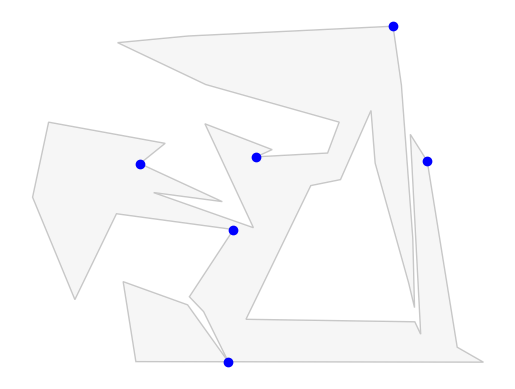

 * Optimal solution size:     6


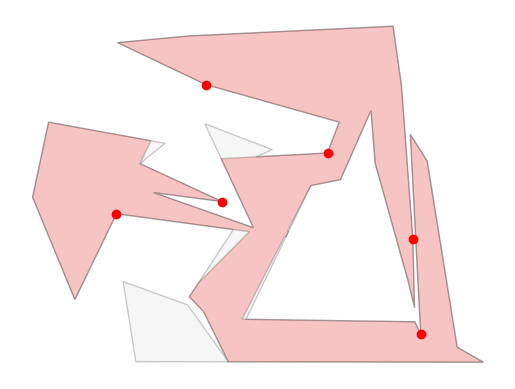

 * Predicted solution size:     6
 * Opt size:     6
 * PtrNet coverage:     0.89730234,      ratio=pred/opt: 1.00000000


In [5]:
# optimal and neural solver
sol_opt    = opt_solver.predict(instance)
sol_sl  = sl_solver.predict(instance,beam_width=4)[0]

# show only opt solution
poly, region, predicted, opt, coverage = evaluate_polygon_visibility(sample,sol_opt)
show(poly, region, None, opt, coverage)

# show all possible predicted solutions
poly, region, predicted, opt, coverage = evaluate_polygon_visibility(sample,sol_sl)
show(poly, region, predicted, opt, coverage)


#### Testbeds

In [6]:
results = {}

dataset_dir = '../dataset/development/test'

testbeds = [{ 
    'name' : 'AGNet_testbed_1',
    'dataset_dir' : dataset_dir,
    'regex' : [
         '.*?-[1-5]\d-', # 1-5 tens size
         '.*?-[6-9]\d-', # 6-9 tens sizes,
         '.*?-1\d\d-', # 100s size  
    ] 
},

{ 
    'name' : 'AGNet_testbed_2',    
    'dataset_dir' : dataset_dir,
    'regex' : [
         '.*?-2\d\d-', # 200s
         '.*?-3\d\d-', # 300s
         '.*?-4\d\d-', # 400s  
        '.*?-5\d\d-', # 500s  
    ] 
}
]

# Evaluate model
evaluator = Evaluator(sl_solver)


In [7]:
"""
_ = evaluator.stats(testbeds[0])
_ = evaluator.stats(testbeds[1])
"""

'\n_ = evaluator.stats(testbeds[0])\n_ = evaluator.stats(testbeds[1])\n'

In [8]:
"""
_ = evaluator.boxplot(testbeds[0])
_ = evaluator.boxplot(testbeds[1])
"""

'\n_ = evaluator.boxplot(testbeds[0])\n_ = evaluator.boxplot(testbeds[1])\n'

## Discussion

Several questions are needed to be answered to justify our architecture:
 1. *Why do we need Pointer Network architecture?*

     > ANSWER: It is hard to implement hard contraints in neural network models. We consider Vertex guards on Art Gallery problem which can be modeled with pointers.

 2. *What is the purpose of multiple encoders-decoders?*

     > ANSWER: Art Gallery problems doesn't have unique solutions. We tried to find different coding of solution so we can infer which solution is the best

 3. *Why do you need to use `CovNet`?*
 
     > ANSWER: `Covnet` as a regression model tries to evaluate coverage of polygon given the solution. The purpose of this is to answer can we encode such geoemtric information in NN? If yes, than our model during the inference doesn't need any geometric information.

4. *Why use only 5 solution clusters?*
    > ANSWER: It was arbitrary, but any larger number of solution clusters will make our model more architecturally complex.

# Unsupervised Art Gallery Solver

## REINFORCE approach

In [9]:
# load model
rl_model  = '../models/reinforce/trained_models/ne-10_bs-64_hs-256_hv-256_wd-0.01_lr-0.0001_ss-100_wt_cov-0.6/best_model.pth' 

#opt value
opt_solver = Opt()

# PTrNet search
rl_solver  = AGNetSearch(rl_model)

Model loaded successfully.


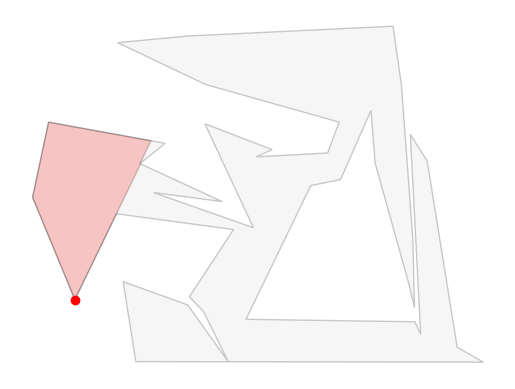

 * Predicted solution size:     1
 * Opt size:     6
 * PtrNet coverage:     0.16497341,      ratio=pred/opt: 0.16666667


In [ ]:
# optimal and neural solver
sol_opt    = opt_solver.predict(instance)
sol_rl     = rl_solver.predict(instance)[0]
sol_all    = np.arange(len(sample.points))

# show only opt solution
poly, region, predicted, opt, coverage = evaluate_polygon_visibility(sample,sol_opt)
show(poly, region, None, opt, coverage)

# show all possible predicted solutions
poly, region, predicted, opt, coverage = evaluate_polygon_visibility(sample,sol_rl)
show(poly, region, predicted, opt, coverage)

# show supervised solution
poly, region, predicted, opt, coverage = evaluate_polygon_visibility(sample,sol_sl)
show(poly, region, predicted, opt, coverage)

# show supervised solution
poly, region, predicted, opt, coverage = evaluate_polygon_visibility(sample,sol_all)
show(poly, region, predicted, opt, coverage)

In [11]:
# evaluate testbeds
evaluator = Evaluator(rl_solver)

In [12]:
"""
_ = evaluator.stats(testbeds[0])
_ = evaluator.stats(testbeds[1])
"""

'\n_ = evaluator.stats(testbeds[0])\n_ = evaluator.stats(testbeds[1])\n'